<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
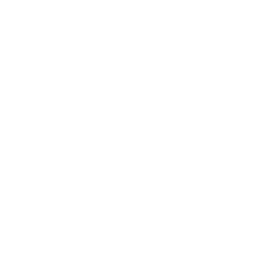
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Προφίλ Ποσών Τραπεζικών Συναλλαγών</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Λιανική Τραπεζική / Ανάλυση Πελατών &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Εκτελεστική Σύνοψη

Αυτό το παράδειγμα σκιαγραφεί τα ποσά συναλλαγών λιανικής τραπεζικής με την PROC MEANS. Χρησιμοποιεί πολυεπίπεδη επεξεργασία κλάσεων (`WAYS 1 2 3`) για να παράγει συνόψεις μίας, δύο και τριών διαστάσεων του `TXN_AMOUNT` ανά κανάλι, πλαίσιο προϊόντος και τμήμα πελατών σε ένα μόνο πέρασμα, με επεξεργασία τύπου BY-group που διαχωρίζει κάθε προφίλ ανά περιοχή. Ένα δεύτερο βήμα PROC MEANS υπολογίζει εκατοστημόρια της άνω ουράς (P95, P99) ανά περιοχή και κανάλι, ως υποψήφια όρια για ειδοποιήσεις κατά της νομιμοποίησης εσόδων από παράνομες δραστηριότητες. Η αφήγηση παρακάτω βασίζεται αποκλειστικά στις τιμές που πράγματι παρήγαγε η διαδικασία σε αυτό το καθολικό 100 συναλλαγών.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.BANK_TRANSACTIONS | Συνθετικό καθολικό συναλλαγών λιανικής τραπεζικής με περιοχή, κανάλι και τμήμα πελατών | 100 |


---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού καθολικού συναλλαγών λιανικής
   τραπεζικής. Αυτό το παράδειγμα εκτελείται σε λειτουργία
   χωρίς άδεια χρήσης, η οποία περιορίζει την έξοδο σε 100
   παρατηρήσεις, οπότε προσαρμόζουμε το καθολικό ώστε να έχει
   ακριβώς 100 συναλλαγές και διατηρούμε το πλέγμα ταξινόμησης
   συμπαγές (2 περιοχές x 3 κανάλια x 3 τμήματα). Αυτό
   διατηρεί κάθε πολυδιάστατο κελί αρκετά γεμάτο ώστε οι μέσοι
   όροι, οι τυπικές αποκλίσεις και τα εκατοστημόρια να είναι
   ενημερωτικά.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.bank_transactions;
    CALL streaminit(42);
    LENGTH region $40 channel $40 segment $40;
    ΕΠΑΝΑΛΗΨΗ txn_id = 1 ΕΩΣ 100;
        _region_pick = int(rand('uniform') * 2) + 1;
        ΕΑΝ _region_pick = 1 ΤΟΤΕ region = 'ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ';
        ΑΛΛΙΩΣ region = 'ΔΥΤΙΚΑ';

        _channel_pick = int(rand('uniform') * 3) + 1;
        ΕΑΝ _channel_pick = 1 ΤΟΤΕ channel = 'ΚΑΤΑΣΤΗΜΑ';
        ΑΛΛΙΩΣ ΕΑΝ _channel_pick = 2 ΤΟΤΕ channel = 'ΔΙΑΔΙΚΤΥΟ';
        ΑΛΛΙΩΣ channel = 'ΕΜΒΑΣΜΑ';

        _segment_pick = int(rand('uniform') * 3) + 1;
        ΕΑΝ _segment_pick = 1 ΤΟΤΕ segment = 'ΜΑΖΙΚΟ';
        ΑΛΛΙΩΣ ΕΑΝ _segment_pick = 2 ΤΟΤΕ segment = 'ΕΥΚΑΤΑΣΤΑΤΟ';
        ΑΛΛΙΩΣ segment = 'ΠΡΕΜΙΕΡ';

        /* Το ποσό κλιμακώνεται ανάλογα με το επίπεδο αξίας του τμήματος πελατών */
        ΕΑΝ segment = 'ΠΡΕΜΙΕΡ' ΤΟΤΕ
            txn_amount = round(rand('exponential') * 4000 + 100, 0.01);
        ΑΛΛΙΩΣ ΕΑΝ segment = 'ΕΥΚΑΤΑΣΤΑΤΟ' ΤΟΤΕ
            txn_amount = round(rand('exponential') * 1500 + 50, 0.01);
        ΑΛΛΙΩΣ
            txn_amount = round(rand('exponential') * 500 + 10, 0.01);
        /* Τα εμβάσματα μεταφέρουν σημαντικά μεγαλύτερα ποσά */
        ΕΑΝ channel = 'ΕΜΒΑΣΜΑ' ΤΟΤΕ
            txn_amount = txn_amount * 3;
        txn_date = '01JAN2026'd + int(rand('uniform') * 90);
        account_id = cat('ACCT-', PUT(int(rand('uniform') * 5000) + 1, z6.));
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ _region_pick _channel_pick _segment_pick;
    ΜΟΡΦΗ txn_date date9. txn_amount dollar12.2;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.bank_transactions


NOTE: Wrote work.bank_transactions (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

In [2]:
/* --------------------------------------------------------
   Βασικός όγκος συναλλαγών ανά περιοχή και κανάλι
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ region ΕΤΙΚΕΤΑ='Περιοχή', channel ΕΤΙΚΕΤΑ='Κανάλι',
           count(*) AS n_txns ΕΤΙΚΕΤΑ='Αριθμός Συναλλαγών',
           sum(txn_amount) AS total_amount ΜΟΡΦΗ=dollar14.2 ΕΤΙΚΕΤΑ='Συνολικό Ποσό'
    FROM work.bank_transactions
    GROUP ΚΑΤΑ region, channel
    ORDER ΚΑΤΑ region, channel;
QUIT;

                       Περιοχή              Κανάλι                   Αριθμός Συναλλαγών              Συνολικό Ποσό
------------------------------  ------------------  -----------------------------------  -------------------------
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ           ΔΙΑΔΙΚΤΥΟ                                   19                 $60,649.49
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ             ΕΜΒΑΣΜΑ                                   14                 $65,506.08
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ           ΚΑΤΑΣΤΗΜΑ                                   20                 $44,287.32
                        ΔΥΤΙΚΑ           ΔΙΑΔΙΚΤΥΟ                                   24                 $43,677.03
                        ΔΥΤΙΚΑ             ΕΜΒΑΣΜΑ                                   14                 $75,894.42
                        ΔΥΤΙΚΑ           ΚΑΤΑΣΤΗΜΑ                                    9                 $23,436.62



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---


NOTE: PROC SGPLOT data=work.bank_transactions

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


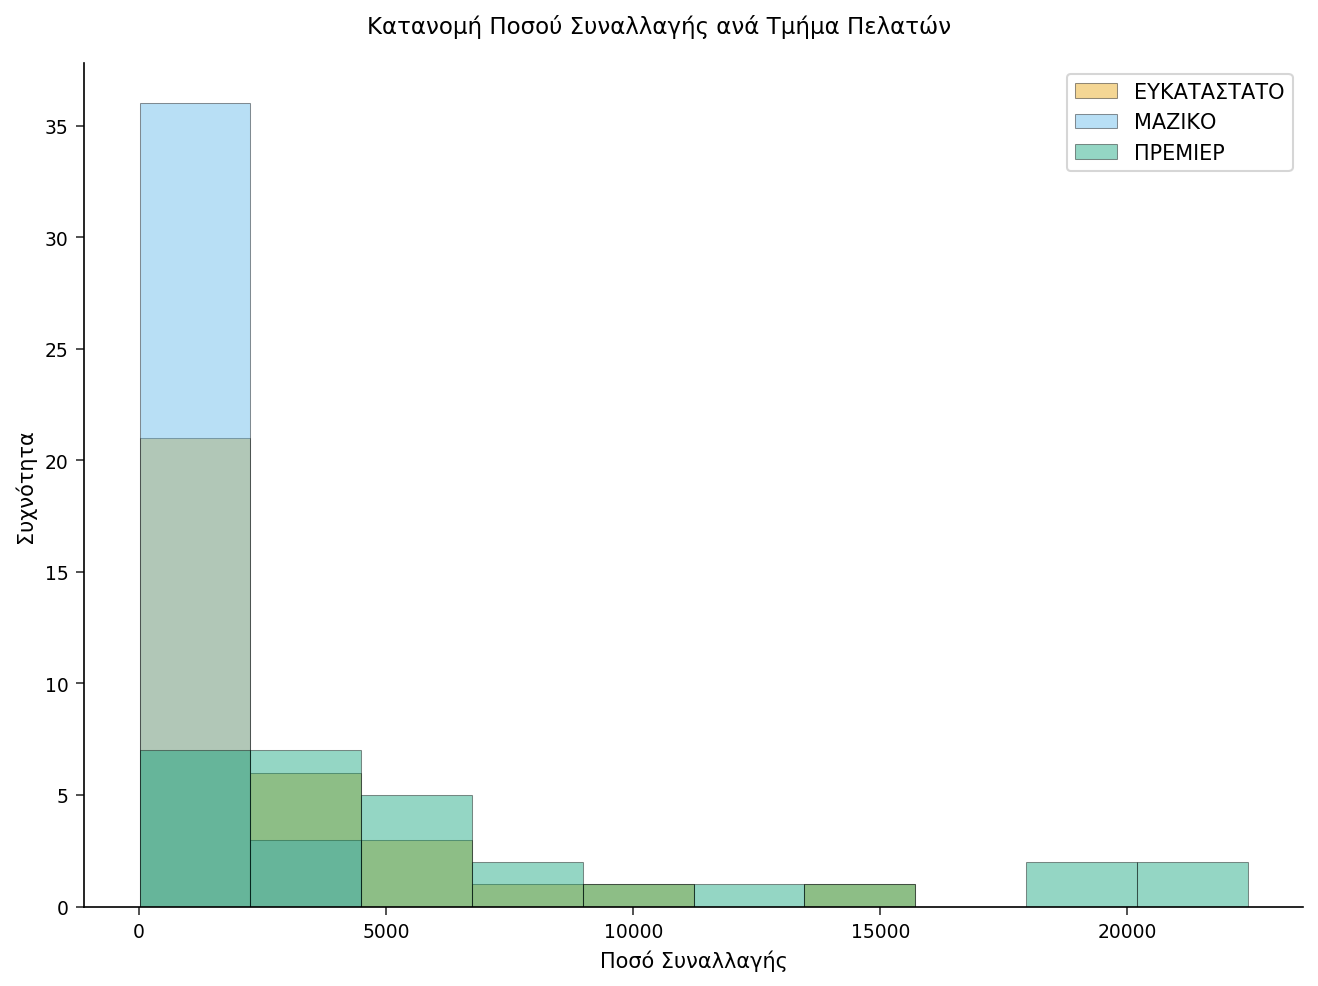

In [3]:
/* --------------------------------------------------------
   Κατανομή ποσών συναλλαγών ανά τμήμα πελατών
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.bank_transactions;
    HISTOGRAM txn_amount / GROUP=segment TRANSPARENCY=0.4;
    XAXIS ΕΤΙΚΕΤΑ='Ποσό Συναλλαγής';
    YAXIS ΕΤΙΚΕΤΑ='Συχνότητα';
    TITLE 'Κατανομή Ποσού Συναλλαγής ανά Τμήμα Πελατών';
ΕΚΤΕΛΕΣΗ;


---

In [4]:
/* --------------------------------------------------------
   Ταξινόμηση κατά περιοχή για επεξεργασία τύπου BY-group
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=work.bank_transactions;
    ΚΑΤΑ region;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC SORT data=work.bank_transactions

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.bank_transactions.
NOTE: Wrote work.bank_transactions (100 rows, 7 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Πολυδιάστατη σκιαγράφηση. Το WAYS 1 2 παράγει κάθε
   συνδυασμό μίας και δύο διαστάσεων των μεταβλητών κλάσης σε
   ένα μόνο πέρασμα· το BY region παράγει ξεχωριστό προφίλ ανά
   περιοχή. Το AUTONAME προσθέτει ως επίθημα κάθε στατιστικό
   μέγεθος στο όνομα της μεταβλητής ανάλυσης.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=work.bank_transactions n mean std MIN MAX q1 q3 MEDIAN;
    ΚΑΤΑ region;
    ΚΛΑΣΗ channel segment;
    WAYS 1 2;
    ΜΕΤΑΒΛΗΤΗ txn_amount;
    ΕΤΙΚΕΤΑ txn_amount = 'Ποσό Συναλλαγής';
    ΕΞΟΔΟΣ out=work.txn_profile
        n= mean= std= MIN= MAX= MEDIAN= q1= q3= / autoname;
ΕΚΤΕΛΕΣΗ;


---------------------------------------- region=ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ -----------------------------------------

                                                  The MEANS Procedure

                              Analysis Variable : txn_amount Ποσό Συναλλαγής

        channel             segment                         N Obs           Mean        Std Dev        Minimum        Maximum  Lower Quartile  Upper Quartile         Median
        --------------------------------------------------------------------------------------------------------------------------------------------------------------------
        ΔΙΑΔΙΚΤΥΟ           ΕΥΚΑΤΑΣΤΑΤΟ                         3        $439.32        $401.53        $100.38        $882.77         $100.38         $882.77        $334.80
        ΔΙΑΔΙΚΤΥΟ           ΜΑΖΙΚΟ                              6        $427.08        $515.23         $91.12      $1,451.42         $153.98         $416.41        $224.79
        ΔΙΑΔΙΚΤΥΟ           ΠΡΕΜΙΕΡ                 


NOTE: PROC MEANS
NOTE: Output dataset work.txn_profile has 30 observations and 13 variables.
NOTE: PROC MEANS statement used.


In [6]:
/* --------------------------------------------------------
   Άντληση της μονοδιάστατης σύνοψης καναλιού (_TYPE_ = 2, όπου
   μόνο το CHANNEL είναι ενεργό) για προβολή πίνακα ελέγχου σε
   επίπεδο καναλιού.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ region ΕΤΙΚΕΤΑ='Περιοχή', channel ΕΤΙΚΕΤΑ='Κανάλι',
           txn_amount_n AS n_transactions ΕΤΙΚΕΤΑ='Αριθμός Συναλλαγών',
           txn_amount_mean AS avg_amount ΜΟΡΦΗ=dollar12.2 ΕΤΙΚΕΤΑ='Μέσο Ποσό',
           txn_amount_median AS median_amount ΜΟΡΦΗ=dollar12.2 ΕΤΙΚΕΤΑ='Διάμεσο Ποσό',
           txn_amount_stddev AS std_amount ΜΟΡΦΗ=dollar12.2 ΕΤΙΚΕΤΑ='Τυπική Απόκλιση'
    FROM work.txn_profile
    ΟΠΟΥ _type_ = 2
    ORDER ΚΑΤΑ region, channel;
QUIT;


                       Περιοχή              Κανάλι                   Αριθμός Συναλλαγών          Μέσο Ποσό             Διάμεσο Ποσό                Τυπική Απόκλιση
------------------------------  ------------------  -----------------------------------  -----------------  -----------------------  -----------------------------
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ           ΔΙΑΔΙΚΤΥΟ                                 19.0          $3,192.08                $1,451.42                      $4,749.86
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ             ΕΜΒΑΣΜΑ                                 14.0          $4,679.01                $2,415.73                      $5,593.67
               ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ           ΚΑΤΑΣΤΗΜΑ                                 20.0          $2,214.37                $1,065.89                      $3,254.59
                        ΔΥΤΙΚΑ           ΔΙΑΔΙΚΤΥΟ                                 24.0          $1,819.88                  $363.46                      $4,602.84
                      


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Όρια άνω ουράς: P95, P99 και το μέγιστο ανά περιοχή και
   κανάλι. Στην παραγωγή, αυτές οι εκτιμήσεις ουράς τροφοδοτούν
   τη βαθμονόμηση ειδοποιήσεων κατά της νομιμοποίησης εσόδων
   από παράνομες δραστηριότητες. Σε ένα καθολικό 100 γραμμών
   τα πλήθη ανά κελί είναι μικρά, οπότε τα εκατοστημόρια είναι
   ενδεικτικά και όχι βαθμονομημένα.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=work.bank_transactions p95 p99 MAX;
    ΚΑΤΑ region;
    ΚΛΑΣΗ channel;
    ΜΕΤΑΒΛΗΤΗ txn_amount;
    ΕΤΙΚΕΤΑ txn_amount = 'Ποσό Συναλλαγής';
    ΕΞΟΔΟΣ out=work.aml_thresholds
        p95= p99= MAX= / autoname;
ΕΚΤΕΛΕΣΗ;


---------------------------------------- region=ΒΟΡΕΙΟΑΝΑΤΟΛΙΚΑ -----------------------------------------

                                                  The MEANS Procedure

                             Analysis Variable : txn_amount Ποσό Συναλλαγής

                                               N
                       channel               Obs       95th Pctl       99th Pctl         Maximum
                       -------------------------------------------------------------------------
                       ΔΙΑΔΙΚΤΥΟ              19      $18,941.55      $18,941.55      $18,941.55
                       ΕΜΒΑΣΜΑ                14      $18,534.36      $18,534.36      $18,534.36
                       ΚΑΤΑΣΤΗΜΑ              20      $10,676.57      $13,443.41      $13,443.41
                       -------------------------------------------------------------------------


------------------------------------------------- region=ΔΥΤΙΚΑ ------------------------------------------------


NOTE: PROC MEANS
NOTE: Output dataset work.aml_thresholds has 8 observations and 7 variables.
NOTE: PROC MEANS statement used.


---

### Ερμηνεία

Το πολυδιάστατο προφίλ επιβεβαιώνει ότι το τμήμα πελατών και το κανάλι καθορίζουν από κοινού το μέγεθος της συναλλαγής. Μέσα στα δισδιάστατα κελιά (κανάλι x τμήμα), οι πελάτες ΠΡΕΜΙΕΡ καταγράφουν τα μεγαλύτερα μέσα ποσά σε κάθε κανάλι όπου εμφανίζονται: στα Δυτικά, οι διαδικτυακές συναλλαγές ΠΡΕΜΙΕΡ έχουν μέσο όρο \$8,879.75 (n=4, μέγιστο \$22,431.64) και οι συναλλαγές εμβάσματος ΠΡΕΜΙΕΡ έχουν μέσο όρο \$11,119.84 (n=4, μέγιστο \$21,880.47), έναντι των διαδικτυακών ΜΑΖΙΚΩΝ Δυτικών με \$289.91 και των ΜΑΖΙΚΩΝ καταστήματος Δυτικών με \$443.53. Στα Βορειοανατολικά, οι διαδικτυακές συναλλαγές ΠΡΕΜΙΕΡ έχουν μέσο όρο \$5,676.90 σε 10 συναλλαγές, ενώ οι διαδικτυακές ΜΑΖΙΚΕΣ συναλλαγές έχουν μέσο όρο \$427.08 — ένα χάσμα τάξης μεγέθους που καθιστά το τμήμα ΠΡΕΜΙΕΡ τον κυρίαρχο προβλεπτικό παράγοντα της αξίας συναλλαγής.

Το βήμα των εκατοστημορίων δείχνει πώς η PROC MEANS τροφοδοτεί τη βαθμονόμηση ορίων. Σε αυτό το καθολικό 100 γραμμών τα πλήθη ανά κελί είναι μικρά, οπότε οι εκτιμήσεις P95/P99 βρίσκονται κοντά στο μέγιστο κάθε κελιού: το διαδικτυακό κανάλι στα Δυτικά φτάνει σε P99 \$22,431.64 και το έμβασμα στα Δυτικά σε \$21,880.47, ενώ το διαδικτυακό κανάλι στα Βορειοανατολικά φτάνει τα \$18,941.55. Το κελί με μία μόνο παρατήρηση για το έμβασμα ΠΡΕΜΙΕΡ στα Βορειοανατολικά (\$18,534.36, τυπική απόκλιση απούσα) υπενθυμίζει ότι τα αραιά κελιά παράγουν ασταθείς εκτιμήσεις ουράς — στην παραγωγή αυτά τα όρια θα υπολογίζονταν εκ νέου στο πλήρες καθολικό, αλλά η μηχανική της διαδικασίας που παρουσιάζεται εδώ είναι ακριβώς αυτή που θα εκτελούσε ένας αναλυτής. Το ιστόγραμμα παραπάνω δείχνει την αναμενόμενη δεξιά ασύμμετρη κατανομή ποσών, με το τμήμα ΠΡΕΜΙΕΡ να εκτείνεται περισσότερο προς την άνω ουρά.


---

In [8]:
/* --------------------------------------------------------
   Εξαγωγή πινάκων σκιαγράφησης και ορίων AML
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.txn_profile
    OUTFILE='transaction_profiles.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.aml_thresholds
    OUTFILE='aml_thresholds_by_region.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.txn_profile outfile=transaction_profiles.csv

NOTE: Exported 30 rows to transaction_profiles.csv.
NOTE: PROC EXPORT data=work.aml_thresholds outfile=aml_thresholds_by_region.csv

NOTE: Exported 8 rows to aml_thresholds_by_region.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με τεχνολογία <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>